Importing Libraries


In [1]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

Test set Image Processing

In [2]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

Loading Model

In [ ]:
import tensorflow as tf

# Load the model without compiling
cnn = tf.keras.models.load_model('trained_plant_disease_model.h5', compile=False)

# Recompile the model
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


Visualising and Performing Prediction on Single image

In [1]:
!pip install opencv-python

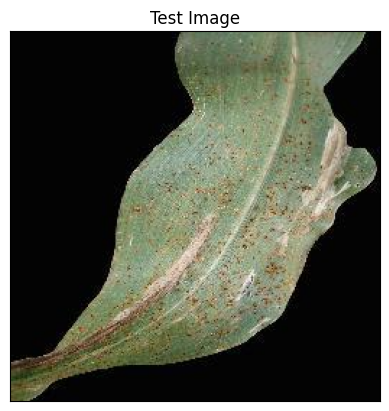

In [28]:
# Importing necessary libraries
import cv2
import matplotlib.pyplot as plt

# Path to the image
image_path = 'test/test/CornCommonRust1.JPG'

# Reading the image in default mode
img = cv2.imread(image_path)

# Converting BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Displaying the image
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()


Testing Model

In [ ]:
# Loading and processing the image
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 [==============================] - 0s 74ms/step


In [30]:
print(predictions)

[[2.1146227e-19 8.1475255e-21 1.1868186e-22 2.8122380e-24 4.0238068e-20
  1.3990801e-16 7.1458618e-23 1.1470956e-16 1.0000000e+00 3.0856070e-20
  5.5125158e-20 3.3593559e-24 2.2630881e-23 2.8945543e-24 7.4010887e-26
  4.0107351e-20 2.1979927e-22 5.3953349e-24 1.7698176e-16 3.4886488e-17
  1.3868852e-12 2.3528405e-26 1.8722222e-20 2.2733365e-27 1.6047174e-27
  4.9118761e-22 5.5191168e-22 9.5744373e-25 1.4259769e-25 8.6100656e-21
  9.8103817e-12 1.5698162e-22 7.1140703e-22 8.2543251e-29 2.1496790e-25
  1.1376627e-28 2.7224031e-29 3.6448431e-20]]


In [31]:
result_index = np.argmax(predictions) # Get the index of the highest probability
print(result_index)

8


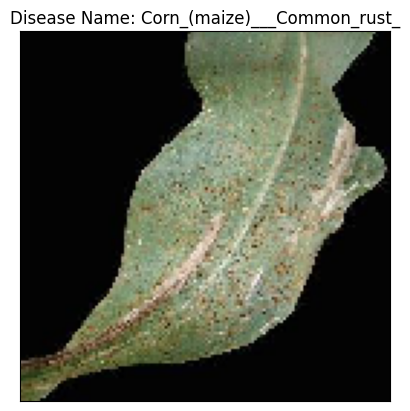

In [32]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(image)  # Display the image
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()